Imports

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, mean_squared_error,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             brier_score_loss, log_loss,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             silhouette_score, f1_score, recall_score, precision_score)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier,
                              StackingClassifier, HistGradientBoostingClassifier)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Consistent aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


load and clean

In [2]:
# --- Load ---
# The CSV has a two-row header: row 0 names the pathogen group,
# row 1 provides the year label. We skip row 0 and assign names manually.
df = pd.read_csv('ThreeYearVirusData.csv', skiprows=1)

df.columns = [
    'Sample_Name', 'Location', 'Cultivar', 'Block', 'Tree_Number', 'Row', 'Tree',
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]

print(f"Shape: {df.shape}")
df.head(3)


Shape: (2408, 16)


,Sample_Name,Location,Cultivar,Block,Tree_Number,Row,Tree,PDV_Y1,PDV_Y2,PDV_Y3,PNRSV_Y1,PNRSV_Y2,PNRSV_Y3,PLMVd_Y1,PLMVd_Y2,PLMVd_Y3
0,AP B-1 5351,Edgefield,Augustprince,B-1,5351,1,10,-,-,-,-,-,-,-,-,-
1,AP B-1 5352,Edgefield,Augustprince,B-1,5352,1,9,-,-,-,-,-,-,-,-,-
2,AP B-1 5353,Edgefield,Augustprince,B-1,5353,1,8,-,-,-,-,-,-,-,-,-


In [3]:
# --- Binary-encode the 9 virus test columns (+/- -> 1/0) ---
VIRUS_COLS = [
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]
for col in VIRUS_COLS:
    df[col + '_bin'] = (df[col] == '+').astype(int)

# --- Encode Location ---z
le_loc = LabelEncoder()
df['Location_enc'] = le_loc.fit_transform(df['Location'])

# --- Encode Cultivar: top-10 + "Other" ---
top10_cultivars = df['Cultivar'].value_counts().head(10).index.tolist()
df['Cultivar_grp'] = df['Cultivar'].apply(lambda x: x if x in top10_cultivars else 'Other')
le_cult = LabelEncoder()
df['Cultivar_enc'] = le_cult.fit_transform(df['Cultivar_grp'])

# --- Numeric position columns ---
df['Row_num']  = pd.to_numeric(df['Row'],  errors='coerce').fillna(df['Row'].value_counts().index[0])
df['Tree_num'] = pd.to_numeric(df['Tree'], errors='coerce').fillna(0)

print("Missing values:", df.isnull().sum().sum())
print("Class distribution â€” PLMVd Year 3:")
print(df['PLMVd_Y3_bin'].value_counts().rename({0:'Negative', 1:'Positive'}))


Missing values: 21
Class distribution â€” PLMVd Year 3:
PLMVd_Y3_bin
Negative    2263
Positive     145
Name: count, dtype: int64


Feature Matrix

In [4]:
# Features used for clustering and dimensionality reduction.
# We include all available prior-year virus data plus metadata.
# PLMVd_Y3_bin is the TARGET â€” kept in df for coloring but NOT in X.
FEATURE_COLS = [
    'PLMVd_Y1_bin', 'PLMVd_Y2_bin',
    'PDV_Y1_bin',   'PDV_Y2_bin',
    'PNRSV_Y1_bin', 'PNRSV_Y2_bin',
    'Location_enc', 'Cultivar_enc',
    'Row_num', 'Tree_num',
]

X_raw = df[FEATURE_COLS].values
y     = df['PLMVd_Y3_bin'].values  # used only for coloring

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}")
print(f"Positive (PLMVd Y3): {y.sum()} / {len(y)}  ({y.mean()*100:.1f}%)")


Feature matrix: (2408, 10)
Positive (PLMVd Y3): 145 / 2408  (6.0%)


In [5]:
n_samples, n_features = X.shape

pca = PCA(n_components=7)
X_transformed = pca.fit_transform(X)

print(f"{7} principal components explain {pca.explained_variance_ratio_.sum()*100:.2f}% of the variance.")

# We center the data and compute the sample covariance matrix.
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
eigenvalues = pca.explained_variance_
for i, (eigenvalue, eigenvector) in enumerate(zip(eigenvalues, pca.components_)):
    print(f"\nPC{i+1} â€” eigenvalue: {eigenvalue:.6f}")
    print(f"  verification dot product: {np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)):.6f}")
    for feature, loading in zip(FEATURE_COLS, eigenvector):
        print(f"  {feature}: {loading:.6f}")

7 principal components explain 90.76% of the variance.

PC1 â€” eigenvalue: 2.529481
  verification dot product: 2.528431
  PLMVd_Y1_bin: -0.078959
  PLMVd_Y2_bin: -0.049347
  PDV_Y1_bin: 0.546011
  PDV_Y2_bin: 0.543127
  PNRSV_Y1_bin: 0.302569
  PNRSV_Y2_bin: 0.368080
  Location_enc: -0.232562
  Cultivar_enc: 0.167357
  Row_num: -0.217887
  Tree_num: -0.204002

PC2 â€” eigenvalue: 1.720199
  verification dot product: 1.719485
  PLMVd_Y1_bin: 0.548946
  PLMVd_Y2_bin: 0.494504
  PDV_Y1_bin: 0.079002
  PDV_Y2_bin: 0.070512
  PNRSV_Y1_bin: 0.231469
  PNRSV_Y2_bin: 0.216561
  Location_enc: 0.256970
  Cultivar_enc: 0.226221
  Row_num: 0.332693
  Tree_num: 0.338440

PC3 â€” eigenvalue: 1.397845
  verification dot product: 1.397264
  PLMVd_Y1_bin: 0.407273
  PLMVd_Y2_bin: 0.516783
  PDV_Y1_bin: -0.066535
  PDV_Y2_bin: -0.065216
  PNRSV_Y1_bin: -0.156444
  PNRSV_Y2_bin: -0.175564
  Location_enc: -0.338315
  Cultivar_enc: -0.095025
  Row_num: -0.336304
  Tree_num: -0.516237

PC4 â€” eigenvalue:

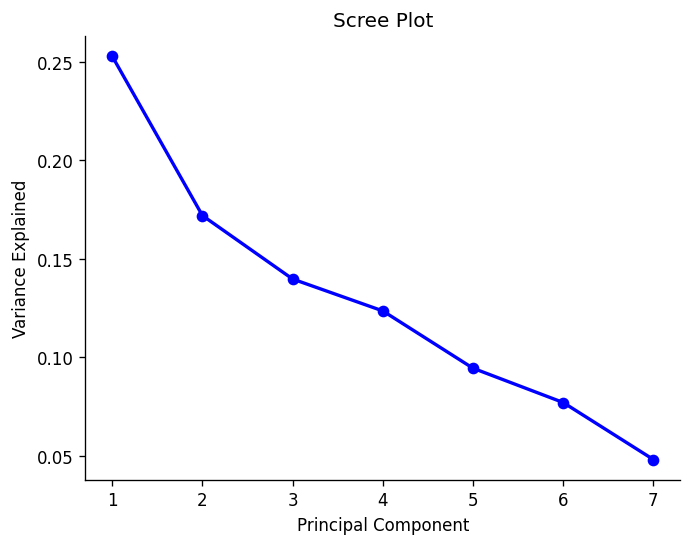

In [6]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

Split data for pca analysis

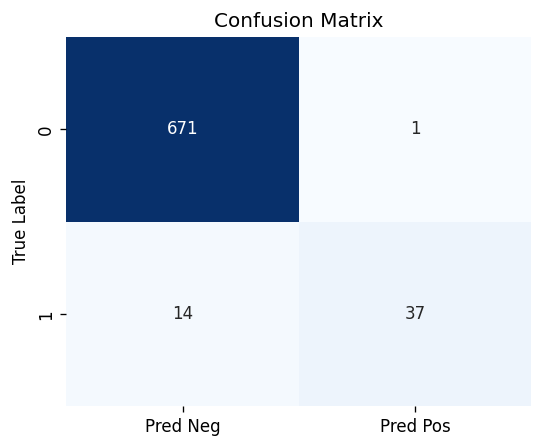

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],)
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

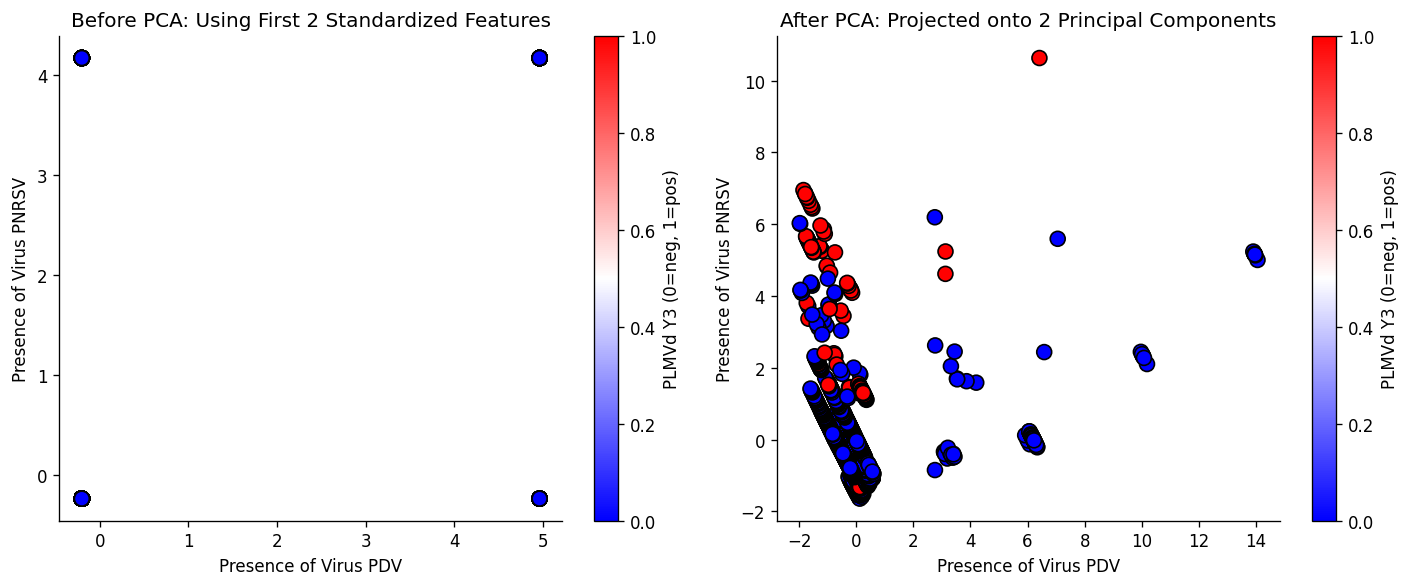

In [8]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap='bwr', edgecolor='k', s=80)
plt.xlabel('Presence of Virus PDV')
plt.ylabel('Presence of Virus PNRSV')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='PLMVd Y3 (0=neg, 1=pos)')

plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y_numeric, cmap='bwr', edgecolor='k', s=80)
plt.xlabel('Presence of Virus PDV')
plt.ylabel('Presence of Virus PNRSV')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='PLMVd Y3 (0=neg, 1=pos)')

plt.tight_layout()
plt.show()

In [9]:
# Compute Recall
r_data = recall_score(y_test, y_pred)

# Compute Precision
p_data = precision_score(y_test, y_pred)

# Compute F1-Score
f1 = f1_score(y_test, y_pred)

# Print results
print("Recall:", r_data, "\n")
print("Precision:", p_data, "\n")
print("F1-Score:", f1, "\n")

Recall: 0.7254901960784313 

Precision: 0.9736842105263158 

F1-Score: 0.8314606741573034 



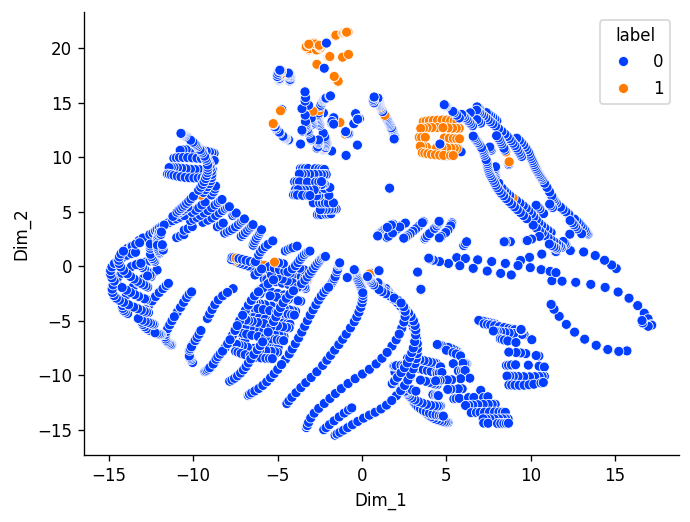

In [10]:
model = TSNE(n_components=3, random_state=42)
tsne_data = model.fit_transform(X)

tsne_df = pd.DataFrame(tsne_data, columns=["Dim_1", "Dim_2", "Dim_3"])
tsne_df["label"] = y

sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2',
               hue='label', palette="bright")
plt.show()

Decision Tree

In [11]:
# 1. Initialize
tree_full = DecisionTreeClassifier(random_state=42, min_samples_split=50, min_samples_leaf=20, ccp_alpha=0.0038)  # DecisionTreeClassifier

# 2. Fit
# ...

tree_full.fit(X_train, y_train)

# 3. Calculate Accuracies
train_acc_full = accuracy_score(y_train, tree_full.predict(X_train))  # float
test_acc_full = accuracy_score(y_test,  tree_full.predict(X_test))  # float

# YOUR CODE HERE

print(f"Training Accuracy (Full Tree): {train_acc_full:.4f}")
print(f"Test Accuracy (Full Tree):     {test_acc_full:.4f}")
print(f"Depth of tree: {tree_full.get_depth()}")

Training Accuracy (Full Tree): 0.9846
Test Accuracy (Full Tree):     0.9806
Depth of tree: 1


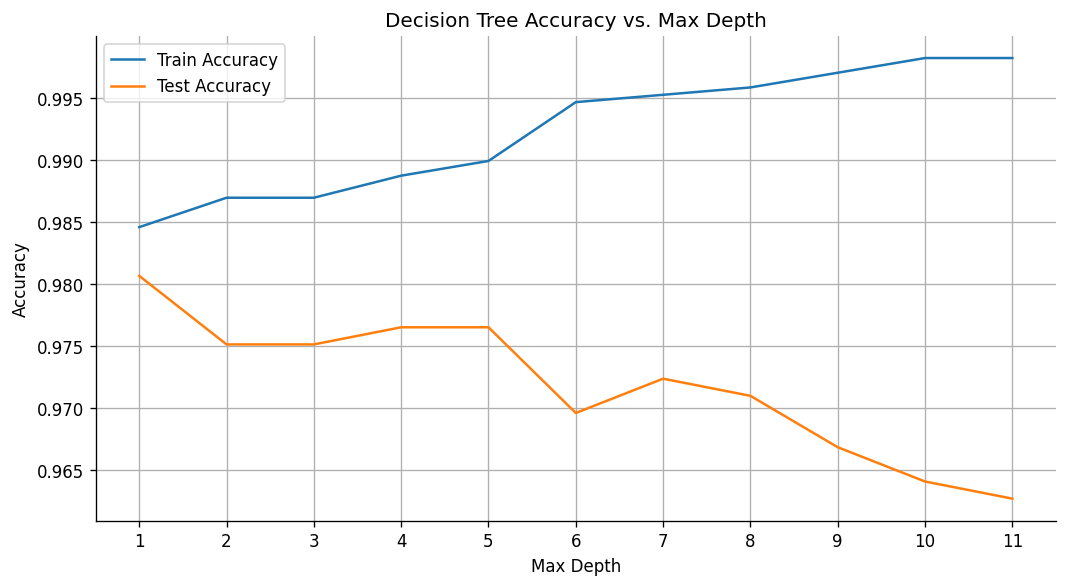

In [12]:
depths = range(1, 12)
train_accs = []
test_accs = []

# 1 & 2. Loop through depths, train, and store accuracies
# ...
for i in depths:
    tree = DecisionTreeClassifier(random_state=42, max_depth=i)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

# 3. Plot
# ...
plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, label='Train Accuracy')
plt.plot(depths, test_accs, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

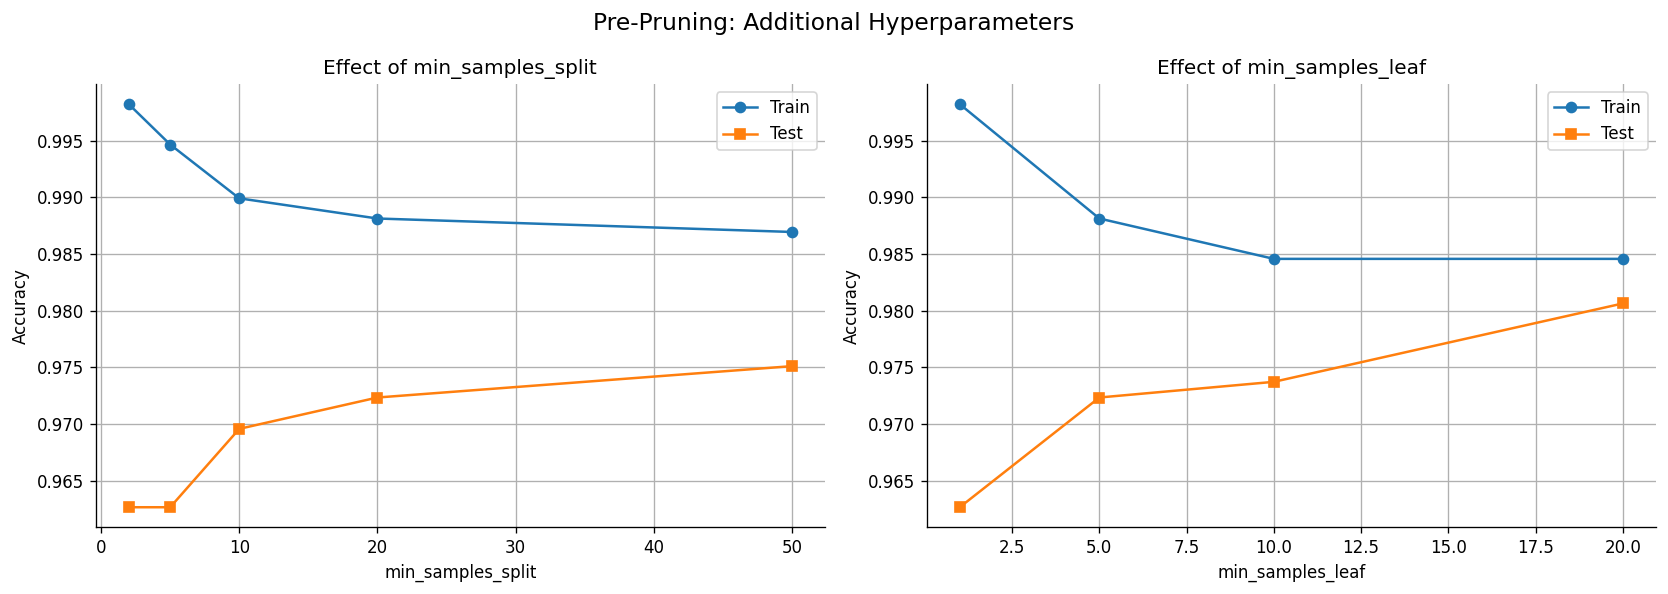

Best min_samples_split: 50
Best min_samples_leaf:  20


In [13]:
split_values = [2, 5, 10, 20, 50]
leaf_values = [1, 5, 10, 20]

train_accs_split = []
test_accs_split = []
train_accs_leaf = []
test_accs_leaf = []

# YOUR CODE HERE
for split in split_values:
    tree = DecisionTreeClassifier(min_samples_split=split, max_depth=None, random_state=42)
    tree.fit(X_train, y_train)
    train_accs_split.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs_split.append(accuracy_score(y_test,  tree.predict(X_test)))

for leaf in leaf_values:
    tree = DecisionTreeClassifier(min_samples_leaf=leaf, max_depth=None, random_state=42)
    tree.fit(X_train, y_train)
    train_accs_leaf.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs_leaf.append(accuracy_score(y_test,  tree.predict(X_test)))

best_min_split = split_values[np.argmax(test_accs_split)]
best_min_leaf  = leaf_values[np.argmax(test_accs_leaf)]

# Plot both curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(split_values, train_accs_split, label='Train', marker='o')
axes[0].plot(split_values, test_accs_split, label='Test', marker='s')
axes[0].set_xlabel('min_samples_split')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Effect of min_samples_split')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(leaf_values, train_accs_leaf, label='Train', marker='o')
axes[1].plot(leaf_values, test_accs_leaf, label='Test', marker='s')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Effect of min_samples_leaf')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Pre-Pruning: Additional Hyperparameters', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best min_samples_split: {best_min_split}")
print(f"Best min_samples_leaf:  {best_min_leaf}")

In [14]:
# Pruning path (provided)
path = DecisionTreeClassifier(random_state=42).fit(
    X_train, y_train
).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_accs_ccp = []
test_accs_ccp = []
# float

# YOUR CODE HERE
for i in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=i, random_state=42)
    tree.fit(X_train, y_train)
    train_accs_ccp.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs_ccp.append(accuracy_score(y_test, tree.predict(X_test)))
    pass
best_alpha = ccp_alphas[np.argmax(test_accs_ccp)]

print(f"Best ccp_alpha: {best_alpha:.4f}")

Best ccp_alpha: 0.0038


Confusion Matrix:
[[671   1]
 [ 13  38]]

Precision: 0.9744
Recall:    0.7451
F1 Score:  0.8444
Accuracy:  0.9806


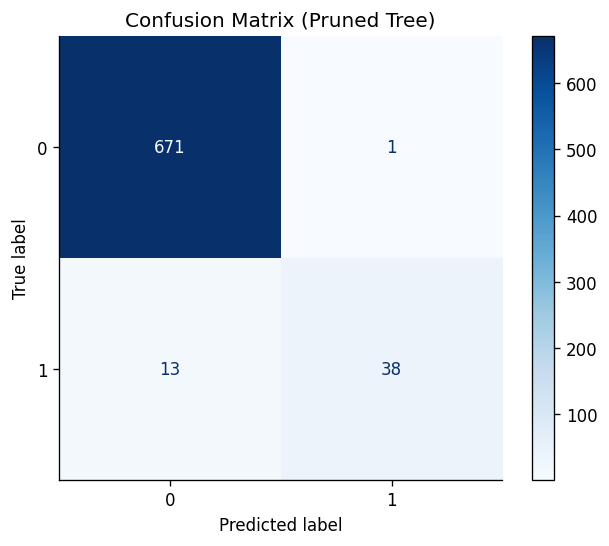

In [15]:
# 2. Predict
y_pred_pruned = tree_full.predict(X_test)

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred_pruned)

# 4. Metrics
precision  = precision_score(y_test, y_pred_pruned)
recall     = recall_score(y_test, y_pred_pruned)
f1         = f1_score(y_test, y_pred_pruned)
acc_pruned = accuracy_score(y_test, y_pred_pruned)

# YOUR CODE HERE

print(f"Confusion Matrix:\n{cm}")
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {acc_pruned:.4f}")

# Visualize
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix (Pruned Tree)")
plt.show()

In [16]:
tn, fp, fn, tp = cm.ravel()
specificity = tn/(tn+fp)  # float
y_prob_pruned = tree_full.predict_proba(X_test)[:, 1]  # NumPy array, shape (90,)
brier   = brier_score_loss(y_test, y_prob_pruned)
logloss = log_loss(y_test, y_prob_pruned)

# YOUR CODE HERE

print(f"Specificity:  {specificity:.4f}")
print(f"Brier Score:  {brier:.4f} (lower is better)")
print(f"Log Loss:     {logloss:.4f} (lower is better)")

Specificity:  0.9985
Brier Score:  0.0197 (lower is better)
Log Loss:     0.1035 (lower is better)


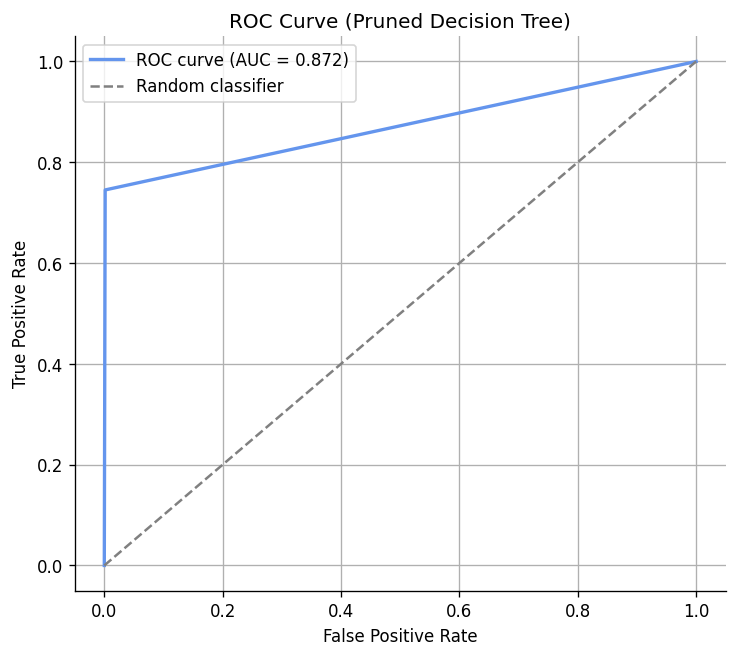

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_pruned)
auc_score = roc_auc_score(y_test, y_prob_pruned)  # float

# YOUR CODE HERE

# Plot (provided)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='cornflowerblue', linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Pruned Decision Tree)')
plt.legend()
plt.grid(True)
plt.show()

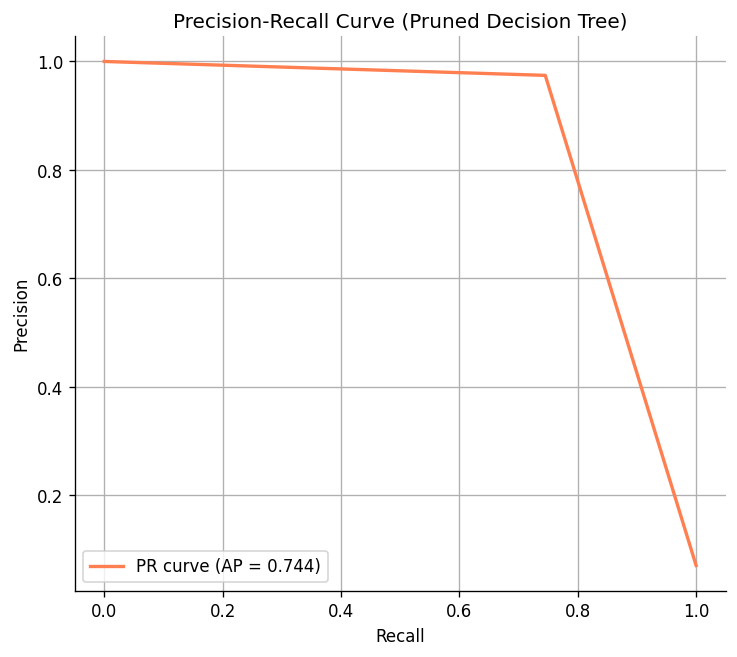

In [18]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, y_prob_pruned)  # NumPy array
avg_precision = average_precision_score(y_test, y_prob_pruned)  # float

# YOUR CODE HERE

# Plot (provided)
plt.figure(figsize=(7, 6))
plt.plot(pr_recall, pr_precision, color='coral', linewidth=2,
         label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Pruned Decision Tree)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# 1. Single Tree
dt_real = DecisionTreeClassifier(random_state=42)  # DecisionTreeClassifier
dt_real.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt_real.predict(X_test))  # float

# 2. Random Forest
rf_real = RandomForestClassifier(random_state=42)  # RandomForestClassifier
rf_real.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_real.predict(X_test))  # float

# YOUR CODE HERE

print(f"Single Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Random Forest Accuracy:        {acc_rf:.4f}")

Single Decision Tree Accuracy: 0.9627
Random Forest Accuracy:        0.9793


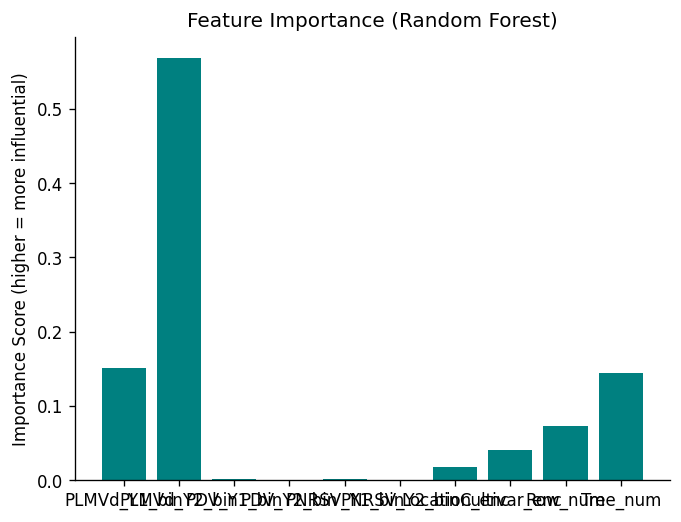

In [20]:
importances = rf_real.feature_importances_  # NumPy array, shape (4,)

# YOUR CODE HERE

# Visualization
plt.bar(FEATURE_COLS, importances, color='teal')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score (higher = more influential)")
plt.show()

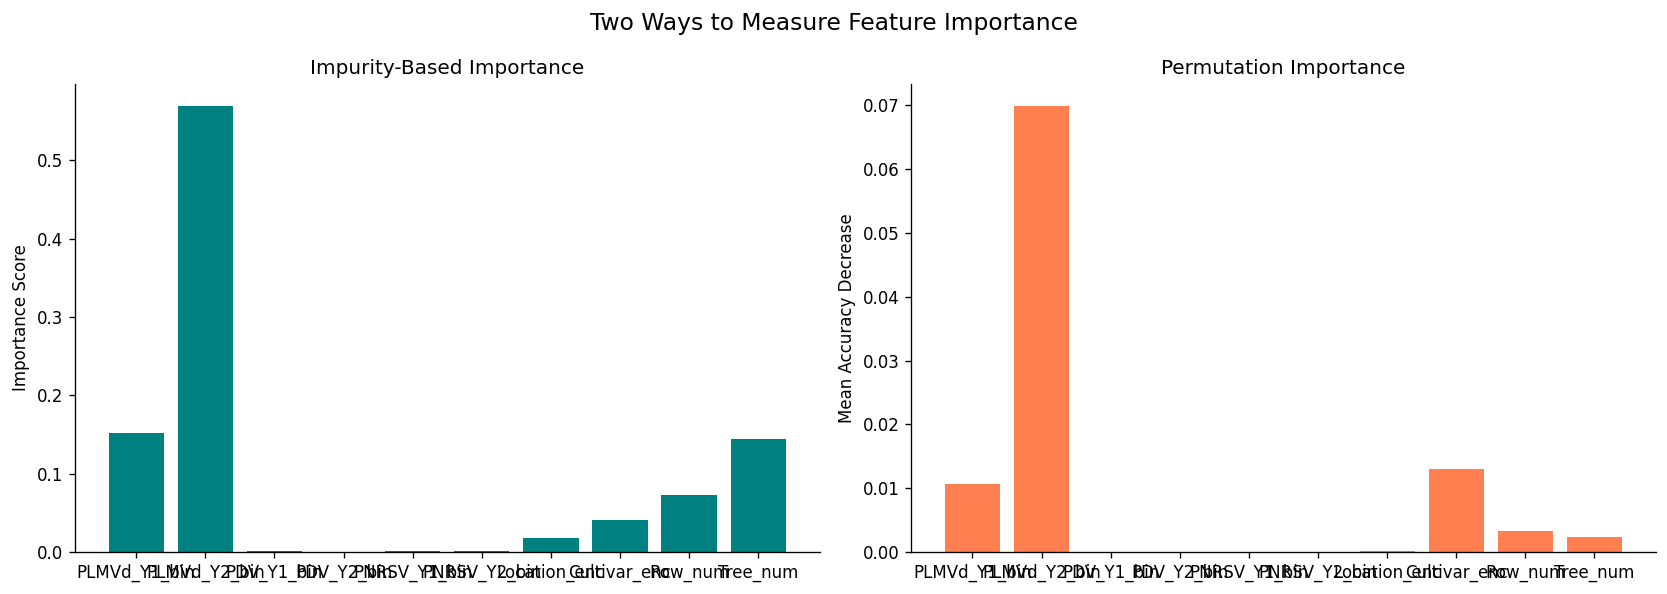

In [21]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf_real, X_test, y_test, n_repeats=10, random_state=42)  # PermutationImportance result object
perm_importances = perm_result.importances_mean  # NumPy array, shape (4,)

# YOUR CODE HERE

# Compare impurity-based vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(FEATURE_COLS, importances, color='teal')
axes[0].set_title("Impurity-Based Importance")
axes[0].set_ylabel("Importance Score")
axes[1].bar(FEATURE_COLS, perm_importances, color='coral')
axes[1].set_title("Permutation Importance")
axes[1].set_ylabel("Mean Accuracy Decrease")
plt.suptitle("Two Ways to Measure Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

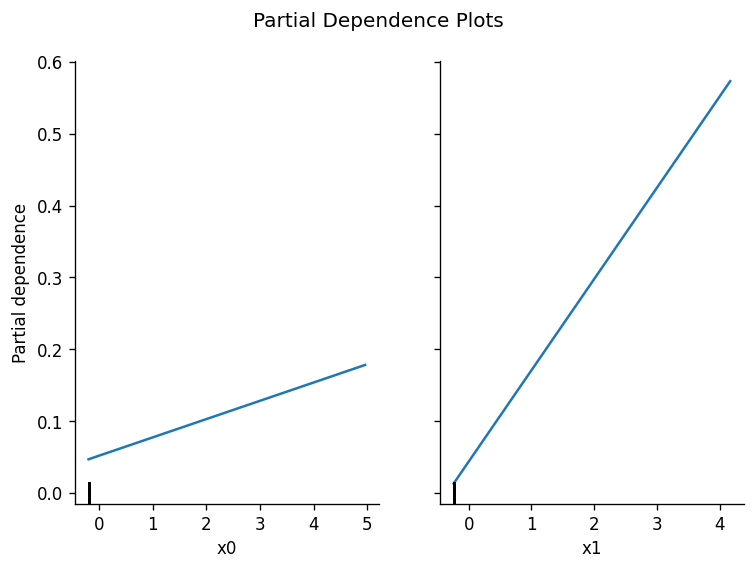

In [22]:
from sklearn.inspection import PartialDependenceDisplay

# PartialDependenceDisplay
pdp_display = PartialDependenceDisplay.from_estimator(estimator=rf_real ,X=X_train, features=[0, 1])

plt.suptitle('Partial Dependence Plots')
plt.tight_layout()
plt.show()

In [23]:
# 1. Standard RF (no class weighting)
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

acc_imb = accuracy_score(y_test, rfc.predict(X_test))  # float
f1_imb = f1_score(y_test, rfc.predict(X_test))  # float
recall_imb = recall_score(y_test, rfc.predict(X_test))  # float

# 2. RF with class_weight='balanced'
rfc_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rfc_balanced.fit(X_train, y_train)
acc_imb_bal = accuracy_score(y_test, rfc_balanced.predict(X_test))   # float
f1_imb_bal = f1_score(y_test, rfc_balanced.predict(X_test))   # float
recall_imb_bal = recall_score(y_test, rfc_balanced.predict(X_test))  # float

# YOUR CODE HERE

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10} {'Recall':>10}")
print(f"{'-'*55}")
print(f"{'Standard RF':<25} {acc_imb:>10.4f} {f1_imb:>10.4f} {recall_imb:>10.4f}")
print(f"{'Balanced RF':<25} {acc_imb_bal:>10.4f} {f1_imb_bal:>10.4f} {recall_imb_bal:>10.4f}")

Model                       Accuracy         F1     Recall
-------------------------------------------------------
Standard RF                   0.9793     0.8315     0.7255
Balanced RF                   0.9779     0.8222     0.7255


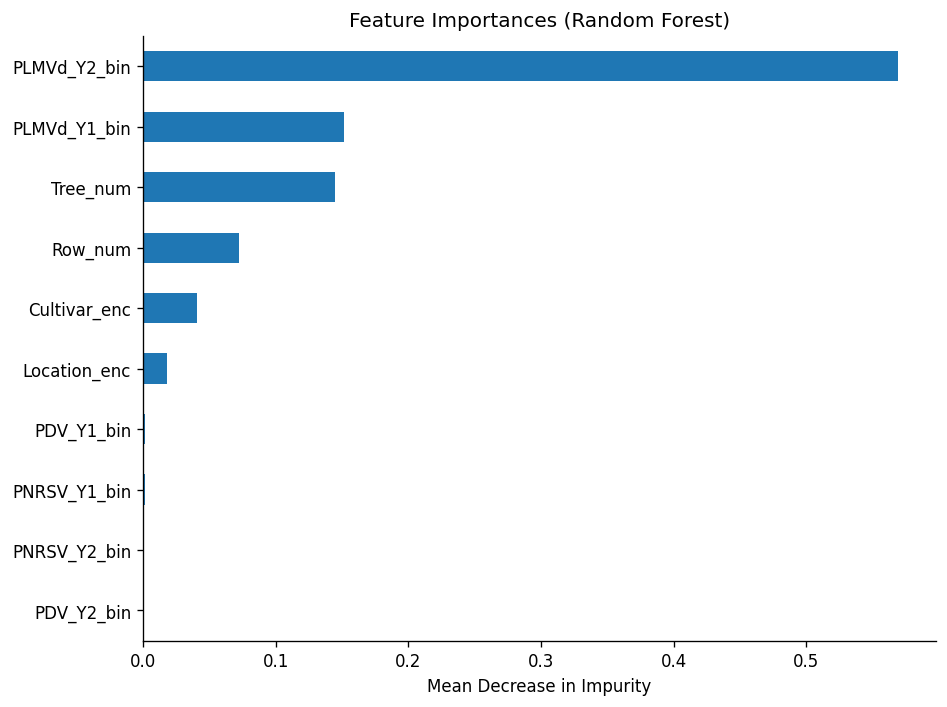

In [24]:
importances = pd.Series(rfc.feature_importances_, index=FEATURE_COLS)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

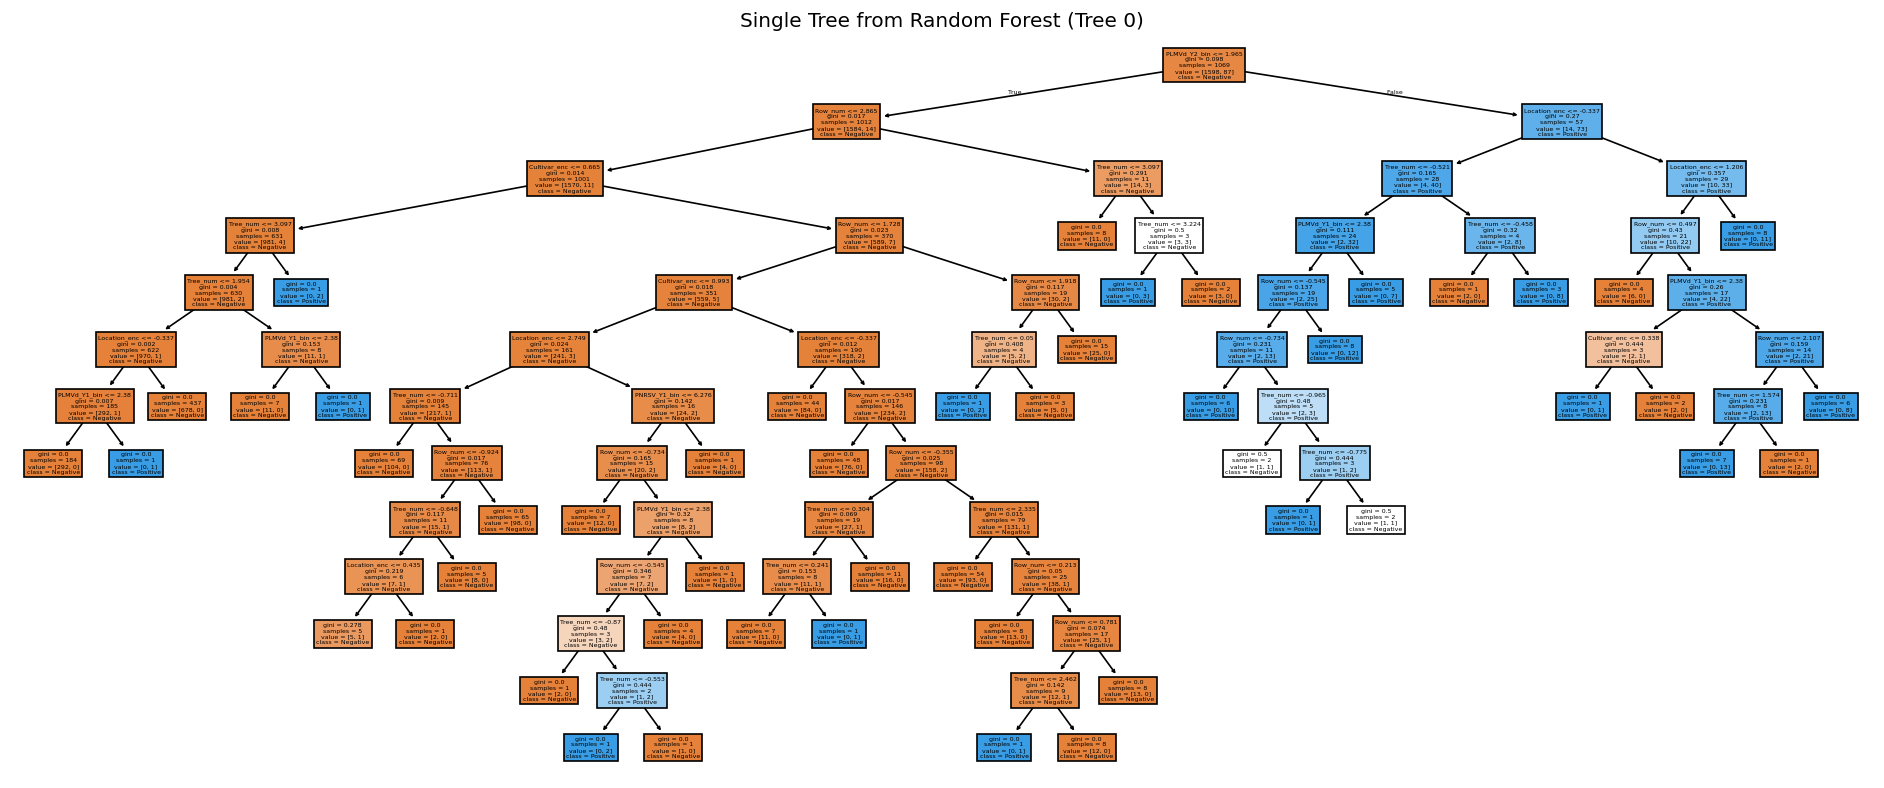

In [25]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(rfc.estimators_[0],          # first tree in the forest
          feature_names=FEATURE_COLS,
          class_names=['Negative', 'Positive'],
          filled=True,
          ax=ax)
plt.title("Single Tree from Random Forest (Tree 0)")
plt.show()

## Target transition trees

In [48]:
newly_infected = df[
    ((df['PDV_Y1']   == '-') & (df['PDV_Y2']   == '+')) |
    ((df['PNRSV_Y1'] == '-') & (df['PNRSV_Y2'] == '+')) |
    ((df['PLMVd_Y1'] == '-') & (df['PLMVd_Y2'] == '+'))
].copy().reset_index(drop=True)

In [54]:
VIRUS_COLS = [
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]
for col in VIRUS_COLS:
    newly_infected[col + '_bin'] = (newly_infected[col] == '+').astype(int)

# --- Encode Location ---
le_loc = LabelEncoder()
newly_infected['Location_enc'] = le_loc.fit_transform(newly_infected['Location'])

# --- Encode Cultivar: top-10 + "Other" ---
top10_cultivars = newly_infected['Cultivar'].value_counts().head(10).index.tolist()
newly_infected['Cultivar_grp'] = newly_infected['Cultivar'].apply(
    lambda x: x if x in top10_cultivars else 'Other'
)
le_cult = LabelEncoder()
newly_infected['Cultivar_enc'] = le_cult.fit_transform(newly_infected['Cultivar_grp'])

# --- Numeric position columns ---
newly_infected['Row_num']  = pd.to_numeric(newly_infected['Row'],  errors='coerce').fillna(0)
newly_infected['Tree_num'] = pd.to_numeric(newly_infected['Tree'], errors='coerce').fillna(0)

# --- Now build feature matrix and target ---
FEATURE_INFECTED_COLS = [
    'PLMVd_Y1_bin',
    'PDV_Y1_bin',
    'PNRSV_Y1_bin',
    'Location_enc', 'Cultivar_enc',
    'Row_num', 'Tree_num',
]

X_infected_raw = newly_infected[FEATURE_INFECTED_COLS].values
y_infected     = newly_infected['PLMVd_Y2_bin'].values  # Y2 as target

scaler = StandardScaler()
X_infected = scaler.fit_transform(X_infected_raw)

print(f"Feature matrix: {X_infected.shape}")
print(f"Positive (PLMVd Y2): {y_infected.sum()} / {len(y_infected)}  ({y_infected.mean()*100:.1f}%)")

Feature matrix: (85, 7)
Positive (PLMVd Y2): 66 / 85  (77.6%)


In [56]:
X_train_infected, X_test_infected, y_train_infected, y_test_infected = train_test_split(
    X_infected, y_infected, test_size=0.2, random_state=42, stratify=y_infected
)

In [57]:
# 1. Standard RF (no class weighting)
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_infected, y_train_infected)

acc_imb = accuracy_score(y_test_infected, rfc.predict(X_test_infected))  # float
f1_imb = f1_score(y_test_infected, rfc.predict(X_test_infected))  # float
recall_imb = recall_score(y_test_infected, rfc.predict(X_test_infected))  # float

# 2. RF with class_weight='balanced'
rfc_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rfc_balanced.fit(X_train_infected, y_train_infected)
acc_imb_bal = accuracy_score(y_test_infected, rfc_balanced.predict(X_test_infected))   # float
f1_imb_bal = f1_score(y_test_infected, rfc_balanced.predict(X_test_infected))   # float
recall_imb_bal = recall_score(y_test_infected, rfc_balanced.predict(X_test_infected))  # float

# YOUR CODE HERE

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10} {'Recall':>10}")
print(f"{'-'*55}")
print(f"{'Standard RF':<25} {acc_imb:>10.4f} {f1_imb:>10.4f} {recall_imb:>10.4f}")
print(f"{'Balanced RF':<25} {acc_imb_bal:>10.4f} {f1_imb_bal:>10.4f} {recall_imb_bal:>10.4f}")

Model                       Accuracy         F1     Recall
-------------------------------------------------------
Standard RF                   1.0000     1.0000     1.0000
Balanced RF                   1.0000     1.0000     1.0000


MSE:  0.1609
R²:   0.1060


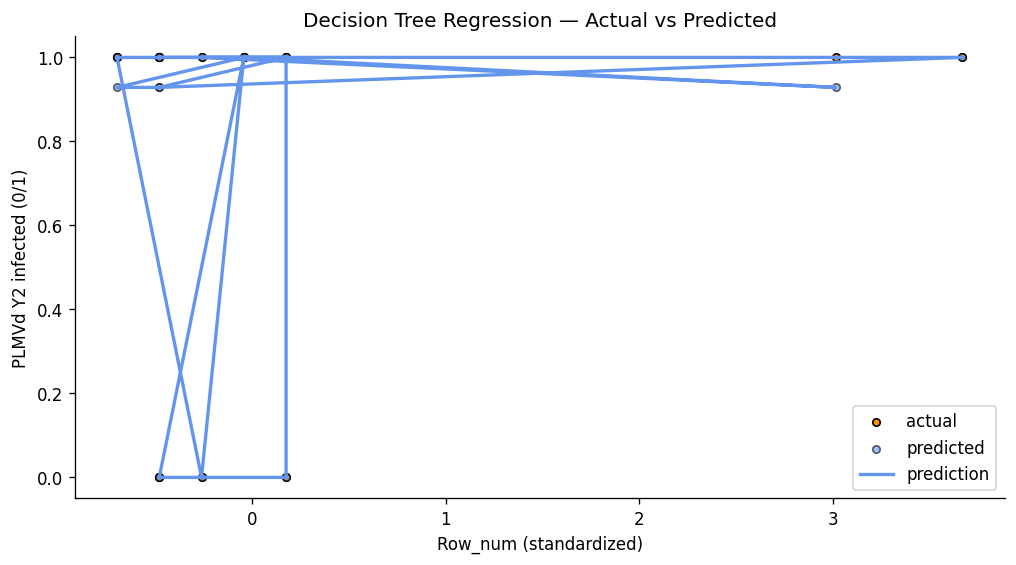

In [ ]:
# 1. Initialize
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)

# 2. Fit
tree_reg.fit(X_train_infected, y_train_infected)

# 3. Predict
y_pred_reg = tree_reg.predict(X_test_infected)

# Metrics
print(f"MSE:  {mean_squared_error(y_test_infected, y_pred_reg):.4f}")
print(f"R²:   {r2_score(y_test_infected, y_pred_reg):.4f}")

# Get the index of Row_num in your feature list
row_idx = FEATURE_INFECTED_COLS.index('Row_num')

x_plot = X_test_infected[:, row_idx]

plt.figure(figsize=(10, 5))
plt.scatter(x_plot, y_test_infected, s=20, edgecolor="black", c="darkorange", label="actual")
plt.scatter(x_plot, y_pred_reg,      s=20, edgecolor="black", c="cornflowerblue", label="predicted", alpha=0.6)
plt.xlabel("Row_num (standardized)")
plt.ylabel("PLMVd Y2 infected (0/1)")
plt.title("Decision Tree Regression — Actual vs Predicted")
plt.legend()
plt.show()